# Integrative Analysis of Breast Cancer Susceptibility Loci and Tumor Immune Programs Reveals Immune-Associated Candidate Genes in Triple-Negative Breast Cancer

---
## Notebook 6 - Functional Characterization of Breast Cancer Susceptibility Genes

### Biological Objective

Genes located within breast cancer susceptibility loci may participate in shared biological processes that contribute to disease initiation.

Rather than examining individual genes in isolation, this notebook investigates whether the complete set of GWAS-mapped susceptibility genes shows enrichment for specific biological functions or molecular pathways.

Functional enrichment analysis provides a systems-level view of the biological mechanisms potentially influenced by inherited breast cancer susceptibility.

In [1]:
import numpy as np
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Candidate Susceptibility Genes

The list of unique genes mapped to genome-wide significant breast cancer susceptibility loci (Notebook 2) is used as the input for functional enrichment analysis.

These genes collectively represent inherited genomic regions associated with breast cancer risk.

In [2]:
gwas_genes_df = pd.read_csv("../data/gwas/gwas_mapped_unique_genes.csv")

In [3]:
gene_list = gwas_genes_df['gene_name'].dropna().unique().tolist()
print(f"Loaded {len(gene_list)} unique GWAS risk genes for enrichment testing.")

Loaded 193 unique GWAS risk genes for enrichment testing.


### 2. Perform Functional Enrichment Analysis

Over-representation analysis (ORA) is performed using Enrichr to determine whether GWAS susceptibility genes are preferentially associated with known biological functions.

Four complementary annotation databases are interrogated:

- Gene Ontology (GO) Biological Process
- MSigDB Hallmark Gene Sets
- KEGG Pathways
- Reactome Pathways

For each database, statistical significance is assessed using enrichment tests with multiple-testing correction.

In [4]:
gene_sets = [
    'GO_Biological_Process_2023',
    'MSigDB_Hallmark_2020',
    'KEGG_2021_Human',
    'Reactome_2022'
]

enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets=gene_sets,
    organism='human',
    outdir=None,  
    cutoff=0.05   
)


results_df = enr.results
results_df.to_csv("../results/tables/gwas_genes_functional_enrichment.csv", index=False)

### 3. Characterize Biological Processes Associated with GWAS Genes

Gene Ontology (GO) Biological Process enrichment identifies cellular functions that are disproportionately represented among breast cancer susceptibility genes.

The bubble plot displays the fifteen most significant GO terms.

Visual encoding:

- **Bubble size** represents the number of susceptibility genes annotated to each process.
- **Bubble color** represents enrichment significance.
- **Position along the x-axis** corresponds to the adjusted statistical significance.

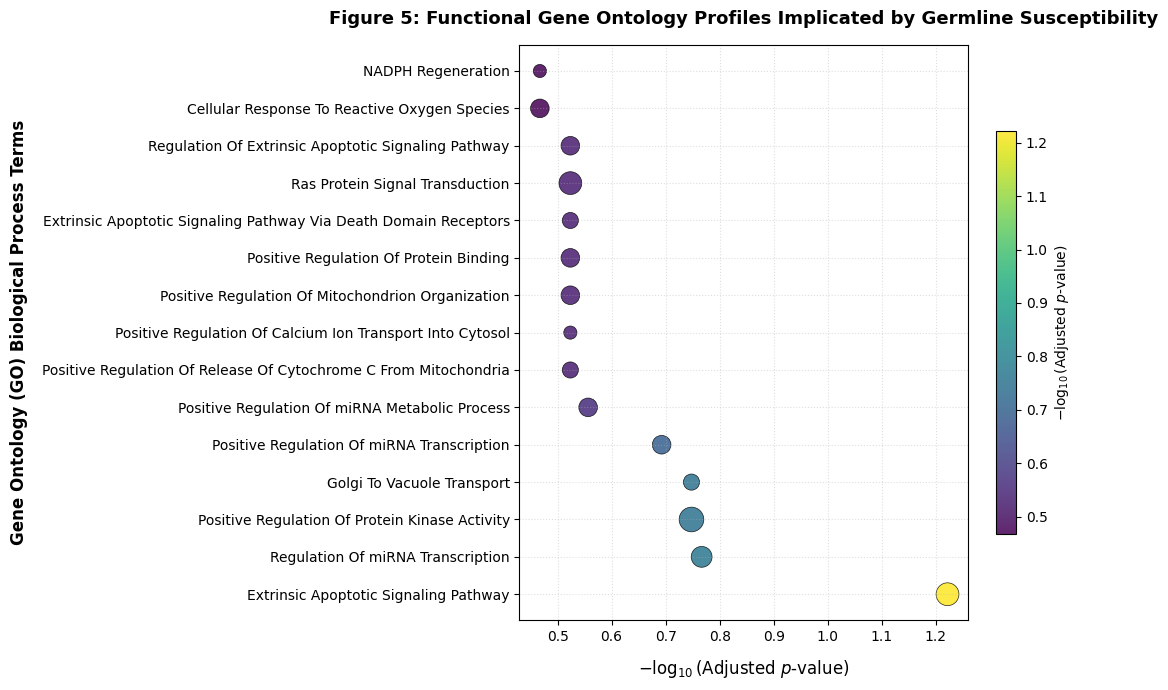

In [5]:
go_filtered = results_df[results_df['Gene_set'] == 'GO_Biological_Process_2023'].copy()
go_top15 = go_filtered.sort_values(by='Adjusted P-value', ascending=True).head(15)

go_top15['minus_log10_padj'] = -np.log10(go_top15['Adjusted P-value'] + 1e-10)
    
go_top15['Gene_Count'] = go_top15['Overlap'].apply(lambda val: int(str(val).split('/')[0]))
    
go_top15['Term'] = go_top15['Term'].apply(lambda x: x.split('(GO:')[0].strip())

fig, ax = plt.subplots(figsize=(11, 7))
    
scatter = ax.scatter(
    x=go_top15['minus_log10_padj'],
    y=go_top15['Term'],
    s=go_top15['Gene_Count'] * 45, 
    c=go_top15['minus_log10_padj'],
    cmap='viridis',
    alpha=0.85,
    edgecolors='black',
    linewidths=0.5
)
    
ax.set_xlabel(r'$-\log_{10}(\text{Adjusted } p\text{-value})$', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Gene Ontology (GO) Biological Process Terms', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Figure 5: Functional Gene Ontology Profiles Implicated by Germline Susceptibility', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, linestyle=':', alpha=0.4)
    
cbar = fig.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label(r'$-\log_{10}(\text{Adjusted } p\text{-value})$', fontsize=10, fontweight='bold')
    
plt.tight_layout()
plt.savefig('../results/figures/go_enrichment_bubble_plot.png', dpi=300, bbox_inches='tight')

### Interpretation

Several biological processes associated with apoptosis, kinase signaling, oxidative stress, and regulation of gene expression were identified among susceptibility genes.

Although statistical significance was generally modest after multiple-testing correction, these findings suggest that inherited susceptibility loci may converge on biological processes involved in cellular survival, stress responses, and transcriptional regulation rather than a single dominant pathway.

These observations provide biological context for subsequent analyses integrating inherited susceptibility with tumor immune activity.

### 4. Evaluate Enrichment of Hallmark Cancer Pathways

MSigDB Hallmark gene sets summarize well-established biological programs commonly altered in cancer.

Testing these pathways provides an opportunity to determine whether inherited breast cancer susceptibility genes preferentially participate in canonical oncogenic processes such as inflammation, apoptosis, DNA damage responses, and interferon signaling.

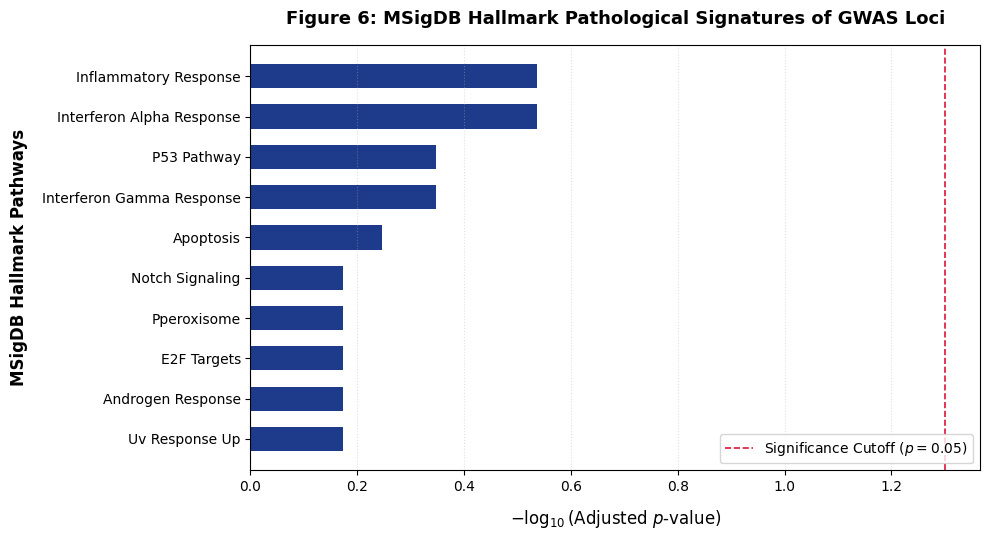

In [6]:
hallmark_filtered = results_df[results_df['Gene_set'] == 'MSigDB_Hallmark_2020'].copy()
hallmark_top10 = hallmark_filtered.sort_values(by='Adjusted P-value', ascending=True).head(10)

hallmark_top10['minus_log10_padj'] = -np.log10(hallmark_top10['Adjusted P-value'] + 1e-10)

hallmark_top10 = hallmark_top10.sort_values(by='minus_log10_padj', ascending=True)
    
hallmark_top10['Term'] = hallmark_top10['Term'].str.replace('HALLMARK_', '').str.replace('_', ' ').str.title()

fig, ax = plt.subplots(figsize=(10, 5.5))
    
bars = ax.barh(
    hallmark_top10['Term'],
    hallmark_top10['minus_log10_padj'],
    color='#1E3A8A', 
    edgecolor='none',
    height=0.6
)
    
ax.axvline(x=-np.log10(0.05), color='crimson', linestyle='--', linewidth=1.2, label='Significance Cutoff ($p = 0.05$)')
ax.set_xlabel(r'$-\log_{10}(\text{Adjusted } p\text{-value})$', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('MSigDB Hallmark Pathways', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Figure 6: MSigDB Hallmark Pathological Signatures of GWAS Loci', 
                 fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.legend(loc='lower right', frameon=True)
    
plt.tight_layout()
plt.savefig('../results/figures/hallmark_enrichment_barplot.png', dpi=300, bbox_inches='tight')

### Interpretation

None of the Hallmark pathways reached statistical significance after adjustment for multiple testing.

Although inflammatory response and interferon signaling exhibited the strongest enrichment trends, these did not exceed the conventional significance threshold (adjusted *p* < 0.05).

This suggests that inherited breast cancer susceptibility genes are broadly distributed across multiple biological programs rather than being concentrated within a single canonical cancer pathway.

Consequently, downstream analyses focus on individual prioritized genes rather than assuming coordinated pathway-level effects.

### Notebook Summary

#### Biological Question Addressed

What biological functions are represented by genes located within inherited breast cancer susceptibility loci?

#### Input

- 193 GWAS-mapped breast cancer susceptibility genes

#### Analyses Performed

- Gene Ontology enrichment analysis
- MSigDB Hallmark pathway enrichment
- KEGG pathway enrichment
- Reactome pathway enrichment

#### Key Findings

Gene Ontology analysis identified enrichment for biological processes related to:

- apoptosis
- regulation of kinase signaling
- oxidative stress responses
- regulation of gene expression

Hallmark pathway analysis identified inflammatory and interferon-related pathways as the strongest enrichment trends; however, no Hallmark pathway reached statistical significance after correction for multiple testing.

Overall, these results suggest that inherited susceptibility genes participate in diverse biological functions rather than converging on a single dominant signaling pathway.

#### Outputs Generated

- `gwas_genes_functional_enrichment.csv`
- Figure 5: GO Biological Process enrichment
- Figure 6: MSigDB Hallmark pathway enrichment